<a href="https://colab.research.google.com/github/ldaniel-hm/eml_tabular/blob/main/MonteCarloTodasLasVisitas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Estudio del algoritmo de Monte Carlo con Políticas ε-soft**

**Descripción**: En este experimento se comparan distintas variantes del algoritmo Monte Carlo, específicamente las versiones on-policy y off-policy, considerando tanto el método de primera visita como el de todas las visitas. El análisis se realiza sobre los entornos de dimensiones 4x4 y 8x8 del entorno FrozenLake de Gymnasium. En este entorno, el agente debe moverse por un mapa hasta llegar a la meta, evitando caer en agujeros.

**Asignatura**: Extensiones de Machine Learning, 2025/2026

**Autores**: 
* Alberto Ortega Pastor
* Manuel Salas Díaz
* Lola Conde Herrera

**Máster de Inteligencia Artificial**

**Facultad de Informática**

-----

This software is licensed under the GNU General Public License v3.0 (GPL-3.0), with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html

----

## **1. Preparación del Entorno**

Para la preparación del entorno, en primer lugar se instalan las librerías necesarias para utilizar el entorno `gymnasium`.

A continuación, se importan las librerías necesarias para la ejecución del notebook.

In [1]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import random
import torch
import gc

from src.ploting import *

from src.agents.AgenteMC_OnPolicy import AgenteMC_OnPolicy
from src.agents.AgenteMC_OffPolicy import AgenteMC_OffPolicy
from src.agents.agent import Agent

Una vez importadas las librerías, se configuran las semillas para los números aleatorios con el fin de garantizar la reproducibilidad de los resultados.

In [2]:
#@title Se fijan las semillas para números aleatorios

# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Liberación de memoria para evitar problemas de consumo en GPU
gc.collect() # Ejecuta el recolector de basura de Python
torch.cuda.empty_cache() # Vacía la caché de memoria en GPU

# Depuración de errores en CUDA
os.environ['CUDA_LAUNCH_BLOCKING'] = '1' # Muestra errores de CUDA en el punto exacto donde ocurren
# Configuración de la semilla para reproducibilidad
seed = 2024 # Se define una semilla fija

# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla

# Fijar la semilla en Python
os.environ['PYTHONHASHSEED'] = str(seed) # Evita variabilidad en hashing de Python

# Fijar la semilla en PyTorch
torch.manual_seed(seed) # Asegura resultados reproducibles en operaciones de PyTorch
if torch.cuda.is_available(): # Si hay GPU disponible
    torch.cuda.manual_seed(seed) # Fija la semilla para la GPU
    torch.backends.cudnn.deterministic = True # Hace las operaciones de CUDNN determinísticas
    torch.backends.cudnn.benchmark = False # Desactiva optimizaciones de CUDNN para evitar variabilidad

Usando dispositivo: cuda


A continuación, se declaran las siguientes constantes:

- El directorio donde se almacenan los vídeos generados
- El nombre del entorno (FrozenLake)
- El tipo de renderizado del entorno

In [3]:
#@title Definición de constantes
video_folder = "./videos"
name = 'FrozenLake-v1'
render = "rgb_array"

Por último, se crean las instancias del entorno FrozenLake en sus versiones 4x4 y 8x8. Para facilitar la interpretación de los resultados, se utiliza la versión no resbaladiza.

In [4]:
#@title Importamos el lago helado

env4 = gym.make(name, is_slippery=False, map_name="4x4", render_mode=render) 
env8 = gym.make(name, is_slippery=False, map_name="8x8", render_mode=render)

## **2. Implementación de Monte Carlo: métodos de primera visita y de todas las visitas**

A continuación, se implementa el método de todas las visitas del algoritmo Monte Carlo.

In [5]:
#@title Método de todas las visitas

def monte_carlo_all_visit(env: gym.Env, agente:Agent, num_episodes=5000):
    """Realiza Monte Carlo todas las visitas durante *num_episodes* episodios, con el agente *agente* en el entorno *env*.
    
    Parámetros:
    - env: Entorno en el que aprende el agente
    - agente: Agente que realiza el aprendizaje
    - num_episodes: Número de episodios que realiza el agente
    
    Devuelve:
    - list_stats: Lista con la evolución de la recompensa media en cada episodio
    - all_episode_lengths: Lista con la duración en pasos de cada episodio
    """
    # Recompensa total
    stats = 0.0
    # Lista con la evolución de la recompensa media
    list_stats = [stats]
    # Lista con la duración de cada episodio
    all_episode_lengths = [] 
    # Cada cuántos episodios se muestra el progreso para que se muestre 10 veces
    step_display = max(1, num_episodes // 10)

    for t in tqdm(range(num_episodes)):
        state, info = env.reset(seed=seed)
        done = False
        # Información de cada paso para la actualización del agente
        episode = []
        # Recompensa total obtenida en el episodio actual
        result_sum  = 0.0
        while not done:
            # Obtiene la acción a ejecutar en el estado actual
            action = agente.get_action(state, t)
            # Realiza la acción en el entorno
            new_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            # Acumula la recompensa total
            result_sum += reward
            # Guarda el estado, la acción y la recompensa inmediata
            episode.append((state, action, reward))
            state = new_state

        # Fase de actualización del agente
        agente.update(episode)    
        # Se guardan los datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))
        all_episode_lengths.append(len(episode))
        # Muestra el progreso del algoritmo cuando corresponde
        if t % step_display == 0 and t != 0:
            print(f"Episode: {t}, Avg Return: {stats/t:.2f}, Epsilon: {agente.epsilon:.3f}")
    # Devuelve las estadísticas del aprendizaje
    return list_stats, all_episode_lengths

A continuación, se implementa el método de la primera visita del algoritmo Monte Carlo.

In [6]:
#@title Algoritmo de la primera visita

def monte_carlo_first_visit(env:gym.Env, agente:Agent, num_episodes=5000):
    """Realiza Monte Carlo con la primera visita durante *num_episodes* episodios, con el agente *agente* en el entorno *env*.
    
    Parámetros:
    - env: Entorno en el que aprende el agente
    - agente: Agente que realiza el aprendizaje
    - num_episodes: Número de episodios que realiza el agente
    
    Devuelve:
    - list_stats: Lista con la evolución de la recompensa media en cada episodio
    - all_episode_lengths: Lista con la duración en pasos de cada episodio
    """
    # Recompensa total
    stats = 0.0
    # Lista con la evolución de la recompensa media
    list_stats = [stats]
    # Lista con la duración de cada episodio
    all_episode_lengths = [] 
    # Cada cuántos episodios se muestra el progreso para que se muestre 10 veces
    step_display = max(1, num_episodes // 10)

    for t in tqdm(range(num_episodes)):
        state, info = env.reset(seed=seed)
        done = False
        # Información de cada paso para la actualización del agente
        episode = []
        # Recompensa total obtenida en el episodio actual
        result_sum  = 0.0
        while not done:
            # Obtiene la acción a ejecutar en el estado actual
            action = agente.get_action(state, t)
            # Realiza la acción en el entorno
            new_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            # Acumula la recompensa total
            result_sum += reward
            # Guarda el estado, la acción y la recompensa inmediata
            episode.append((state, action, reward))
            state = new_state

        # Fase de actualización del agente
        agente.update_first_visit(episode)    

        # Se guardan los datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))
        all_episode_lengths.append(len(episode))

        # Muestra el progreso del algoritmo cuando corresponde
        if t % step_display == 0 and t != 0:
            print(f"Episode: {t}, Avg Return: {stats/t:.2f}, Epsilon: {agente.epsilon:.3f}")
            
    # Devuelve las estadísticas del aprendizaje
    return list_stats, all_episode_lengths

## **3. Experimentación**

En esta sección, se lleva a cabo la experimentación con las distintas variantes del algoritmo Monte Carlo descritas anteriormente. En concreto, se realizan los siguientes experimentos:

- Política:
   - On policy
   - Off policy

- Actualización del agente una vez finaliza el episodio:
   - Algoritmo de la primera visita
   - Algoritmo de todas las visitas

- Entornos:
   - Entorno 4x4. Se realizan 10000 pasos
   - Entorno 8x8. Se realizan 30000 pasos por la dificultad añadida del entorno 8x8 frente al 4x4

Se utiliza epsilon decaimiento en todos los agentes de acuerdo con la siguiente expresión: $\epsilon = min(1.0, 1000.0/(t+1))$

Se utiliza un factor de descuento de 0.99 en todos los agentes.

Por cada experimento y agente, se muestra:
- La recompensa promedio a lo largo de los episodios
- La longitud de los episodios
- La política aprendida
- Un vídeo del agente desde el inicio de un episodio hasta el final utilizando una política greedy

En primer lugar, se definen las constantes para la experimentación

In [7]:
#@title Constantes para la experimentación
FACTOR_DESCUENTO = 0.99
EPSILON_INICIAL = 0.4 # No se usa porque se usa decaimiento
DECAIMIENTO = True
NUM_EPISODIOS_4x4 = 10000
NUM_EPISODIOS_8x8 = 50000

A continuación, se declara una función para hacer una gráfica de la recompensa promedio a lo largo de los episodios de dos agentes.

In [8]:
#@title Gráfica de la recompensa promedio

def crear_grafica_recompensa_promedio(recompensa_1:list, recompensa_2:list, label1:str, label2:str, titulo:str):
    """Crea una gráfica de las listas de recompensas *recompensa_1* y *recompensa_2*, con las etiquetas *label1* y *label2* respectivamente, y el título de la gráfica *titulo*."""
    
    plt.figure(figsize=(12, 6))
    plt.plot(recompensa_1, label=label1)
    plt.plot(recompensa_2, label=label2, linestyle='--')
    plt.xlabel('Episodios')
    plt.ylabel('Recompensa promedio')
    plt.title(titulo)
    plt.legend()
    plt.grid(True)
    plt.show()

A continuación, se crea una función para mostrar la política greedy de dos agentes, y un frame del entorno.

In [9]:
#@title Gráfica de política

def mostrar_entorno_y_politicas(env:gym.Env, qtable_1, qtable_2, map_size:int, titulo_1:str, titulo_2:str):
    """Muestra el entorno *env* y las políticas aprendidas por dos agentes a partir de sus Q-tables (*qtable_1* y *qtable_2*) con los títulos *titulo_1* y *titulo_2*."""
    qmax_1, dirs_1 = qtable_directions_map(qtable_1, map_size)
    qmax_2, dirs_2 = qtable_directions_map(qtable_2, map_size)

    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

    # Muestra el entorno
    ax[0].imshow(env.render())
    ax[0].axis("off")
    ax[0].set_title("Entorno")

    # Muestra la política del primer agente
    sns.heatmap(
        qmax_1,
        annot=dirs_1,
        fmt="",
        ax=ax[1],
        cmap=sns.color_palette("Blues", as_cmap=True),
        linewidths=0.7,
        linecolor="black",
        xticklabels=[],
        yticklabels=[],
        annot_kws={"fontsize": "xx-large"},
    ).set(title=titulo_1)
    for _, spine in ax[1].spines.items():
        spine.set_visible(True)
        spine.set_linewidth(0.7)
        spine.set_color("black")

    # Muestra la política del segundo agente
    sns.heatmap(
        qmax_2,
        annot=dirs_2,
        fmt="",
        ax=ax[2],
        cmap=sns.color_palette("Greens", as_cmap=True),
        linewidths=0.7,
        linecolor="black",
        xticklabels=[],
        yticklabels=[],
        annot_kws={"fontsize": "xx-large"},
    ).set(title=titulo_2)

    for _, spine in ax[2].spines.items():
        spine.set_visible(True)
        spine.set_linewidth(0.7)
        spine.set_color("black")

    plt.tight_layout()
    plt.show()

### **3.1 Experimentación en el escenario 4x4**

A continuación, se realiza la experimentación del escenario 4x4.

#### **3.1.1 Algoritmo Montecarlo On Policy**

A continuación, se realiza el aprendizaje de los modelos para primera visita y todas las visitas.

In [10]:
# @title Aprendizaje Monte Carlo On-Policy en el escenario 4x4

# Monte Carlo todas las visitas
print("Ejecución de Monte Carlo de todas las visitas:")

agente_MC_On_V4_all = AgenteMC_OnPolicy(
    env4, 
    seed, 
    discount_factor=FACTOR_DESCUENTO, 
    epsilon=EPSILON_INICIAL, 
    decay=DECAIMIENTO, 
    num_episodes=NUM_EPISODIOS_4x4)

list_stats_MC_On_V4_all, all_episode_lengths_MC_On_V4_all = monte_carlo_all_visit(
    env4, 
    agente=agente_MC_On_V4_all, 
    num_episodes=NUM_EPISODIOS_4x4)

# Monte Carlo con primera visita
print("-"*20)
print("Ejecución de Monte Carlo de la primera visita:")

agente_MC_On_V4_first = AgenteMC_OnPolicy(
    env4, 
    seed, 
    discount_factor=FACTOR_DESCUENTO, 
    epsilon=EPSILON_INICIAL, 
    decay=DECAIMIENTO, 
    num_episodes=NUM_EPISODIOS_4x4)

list_stats_MC_On_V4_first, all_episode_lengths_MC_On_V4_first = monte_carlo_first_visit(
    env4, 
    agente=agente_MC_On_V4_first, 
    num_episodes=NUM_EPISODIOS_4x4)

Ejecución de Monte Carlo de todas las visitas:


 19%|█▉        | 1941/10000 [00:00<00:01, 4453.39it/s]

Episode: 1000, Avg Return: 0.02, Epsilon: 0.999
Episode: 2000, Avg Return: 0.10, Epsilon: 0.500


 35%|███▌      | 3529/10000 [00:00<00:01, 4869.53it/s]

Episode: 3000, Avg Return: 0.24, Epsilon: 0.333
Episode: 4000, Avg Return: 0.35, Epsilon: 0.250


...

 72%|███████▏  | 7206/10000 [00:01<00:00, 5075.66it/s]

Episode: 6000, Avg Return: 0.49, Epsilon: 0.167
Episode: 7000, Avg Return: 0.54, Epsilon: 0.143


 88%|████████▊ | 8813/10000 [00:01<00:00, 5159.13it/s]

Episode: 8000, Avg Return: 0.58, Epsilon: 0.125
Episode: 9000, Avg Return: 0.61, Epsilon: 0.111


100%|██████████| 10000/10000 [00:01<00:00, 5039.71it/s]


Una vez realizado el aprendizaje de la primera visita y todas las visitas, se muestra la recompensa promedio.

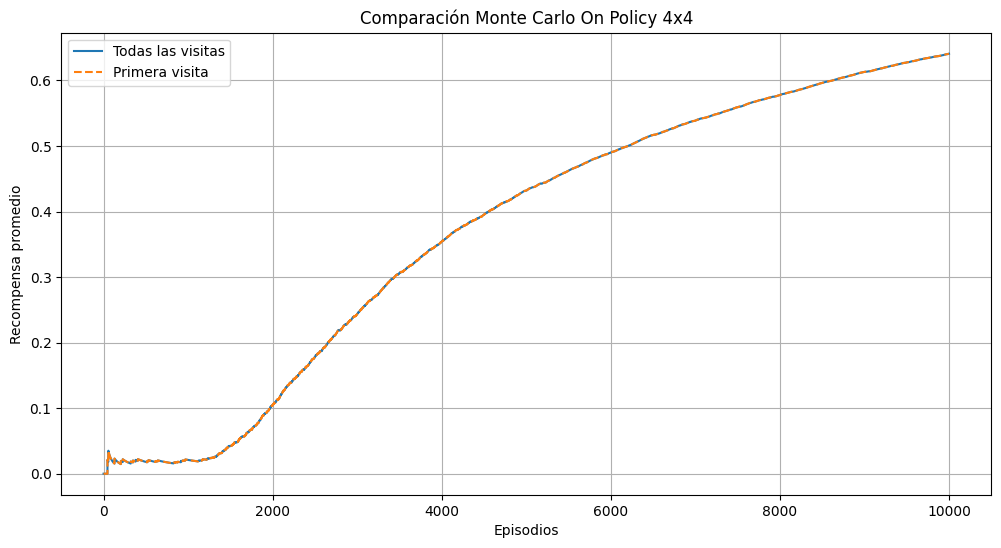

Máxima proporcion Monte Carlo todas las visitas: 0.6408
Máxima proporcion Monte Carlo primera visita: 0.6408


In [11]:
# @title Recompensa promedio Monte Carlo On-Policy en el escenario 4x4

crear_grafica_recompensa_promedio(
    recompensa_1 = list_stats_MC_On_V4_all, 
    recompensa_2 = list_stats_MC_On_V4_first, 
    label1 = "Todas las visitas", 
    label2 = "Primera visita", 
    titulo = "Comparación Monte Carlo On Policy 4x4")

print(f"Máxima proporcion Monte Carlo todas las visitas: {list_stats_MC_On_V4_all[-1]}")
print(f"Máxima proporcion Monte Carlo primera visita: {list_stats_MC_On_V4_first[-1]}")

En la gráfica aparece la recompensa promedio a lo largo de 10000 episodios. En una línea naranja aparece la recompensa del algoritmo de la primera visita, y en azul el algoritmo de todas las visitas.

En esta gráfica, la recompensa de ambos algoritmos es similar durante todo el entrenamiento. Al inicio la recompensa es poca, y a partir de unos 1000 pasos empieza a subir de forma constante, hasta un final de 0.6408, es decir, un 64% de las ocasiones se llega a la meta.

A continuación, se muestra la longitud de los episodios a lo largo del entrenamiento.

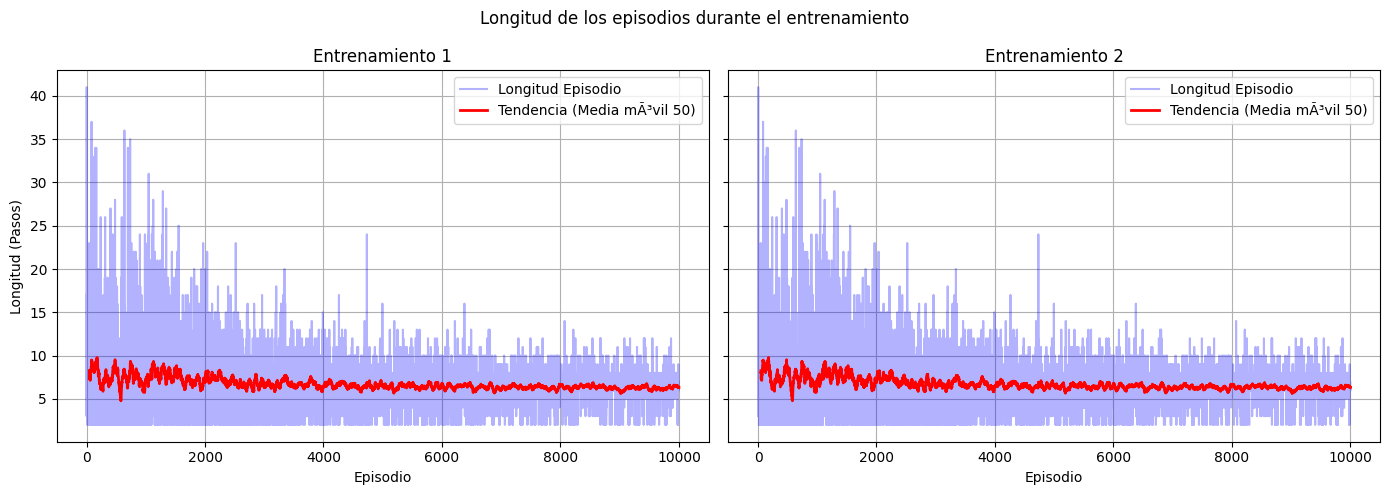

In [12]:
# @title Longitud de los episodios Monte Carlo On-Policy en el escenario 4x4
plot_two_lengths(all_episode_lengths_MC_On_V4_all, all_episode_lengths_MC_On_V4_first)

La longitud de los episodios media se mantiene constante en todos los episodios. Sin embargo, la varianza se reduce cuando evoluciona el aprendizaje.

Se recuerda que los episodios donde se cae en un agujero en vez de llegar a la meta, también pueden tener pocos pasos y aún así ser malos.

El objetivo es una longitud pequeña pero que permita llegar a la meta, y una varianza pequeña en la cantidad de pasos por episodio, lo que se consigue a partir del episodio 4000 en ambos algoritmos.

A continuación, se muestra la política greedy de ambos algoritmos.

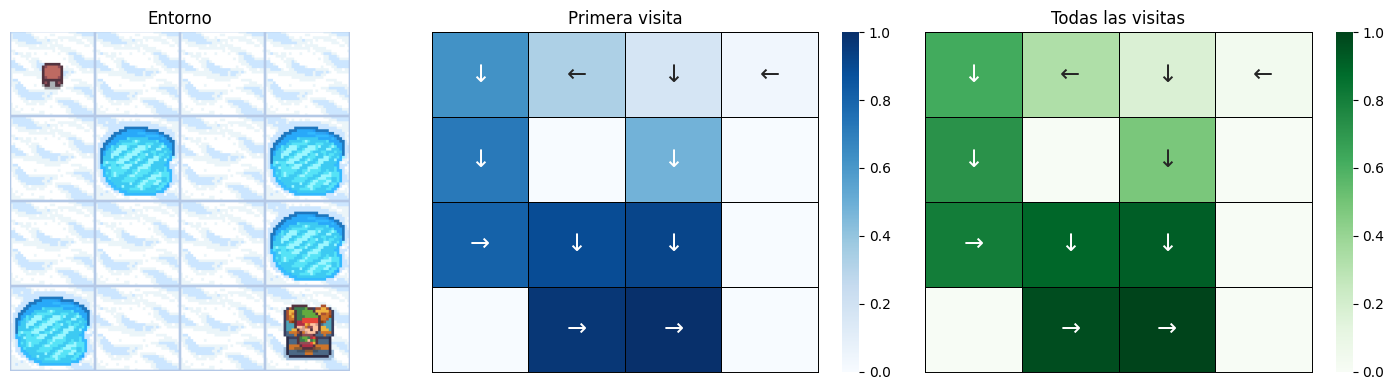

In [13]:
# @title Mostrar el entorno y las políticas greedy de Monte Carlo On-Policy en el escenario 4x4
mostrar_entorno_y_politicas(
    env=env4,
    qtable_1=agente_MC_On_V4_first.Q,
    titulo_1="Primera visita",
    qtable_2=agente_MC_On_V4_all.Q,
    titulo_2="Todas las visitas",
    map_size=4
)

Como se puede observar, los agujeros no tienen una acción asignada porque una vez se cae en un agujero, finaliza el episodio. Ocurre lo mismo con la meta.

Por otra parte, se observa como ambos algoritmos aprenden los mismos caminos. A su vez, cuanto más cerca se encuentra de la meta más color tiene la flecha. Esta intensidad de color no se debe al factor de descuento utilizado en el aprendizaje, que disminuye la recompensa cuantó más alejado del estado que ha dado esta recompensa, pero al ser 0.99 no se nota visualmente en tan pocos pasos. 

Esto se debe a que, dado que se usa una política que aprendió con epsilon-decaimiento, cuanto más alejado de la meta, más probabilidad que en esa parte exploratoria se escogiera una acción en un estado que terminase en caer en un agujero.

#### **3.1.2 Algoritmo Montecarlo Off Policy**

A continuación, se realiza el aprendizaje de los modelos para primera visita y todas las visitas.

In [14]:
# @title Aprendizaje Monte Carlo Off-Policy en el escenario 4x4

# Monte Carlo todas las visitas
print("Ejecución de Monte Carlo de todas las visitas:")

agente_MC_Off_V4_all = AgenteMC_OffPolicy(
    env4, 
    seed, 
    discount_factor=FACTOR_DESCUENTO, 
    epsilon=EPSILON_INICIAL, 
    decay=DECAIMIENTO, 
    num_episodes=NUM_EPISODIOS_4x4)

list_stats_MC_Off_V4_all, all_episode_lengths_MC_Off_V4_all = monte_carlo_all_visit(
    env4, 
    agente=agente_MC_Off_V4_all, 
    num_episodes=NUM_EPISODIOS_4x4)

# Monte Carlo con primera visita
print("-"*20)
print("Ejecución de Monte Carlo de la primera visita:")

agente_MC_Off_V4_first = AgenteMC_OffPolicy(
    env4, 
    seed, 
    discount_factor=FACTOR_DESCUENTO, 
    epsilon=EPSILON_INICIAL, 
    decay=DECAIMIENTO, 
    num_episodes=NUM_EPISODIOS_4x4)

list_stats_MC_Off_V4_first, all_episode_lengths_MC_Off_V4_first = monte_carlo_first_visit(
    env4, 
    agente=agente_MC_Off_V4_first, 
    num_episodes=NUM_EPISODIOS_4x4)

Ejecución de Monte Carlo de todas las visitas:


  7%|▋         | 724/10000 [00:00<00:01, 7216.11it/s]

Episode: 1000, Avg Return: 0.02, Epsilon: 0.999


 22%|██▏       | 2212/10000 [00:00<00:01, 7100.75it/s]

Episode: 2000, Avg Return: 0.10, Epsilon: 0.500


...

Episode: 7000, Avg Return: 0.54, Epsilon: 0.143

 77%|███████▋  | 7685/10000 [00:01<00:00, 5644.57it/s]


Episode: 8000, Avg Return: 0.58, Epsilon: 0.125


100%|██████████| 10000/10000 [00:01<00:00, 5786.76it/s]

Episode: 9000, Avg Return: 0.61, Epsilon: 0.111


Una vez realizado el aprendizaje de la primera visita y todas las visitas, se muestra la recompensa promedio.

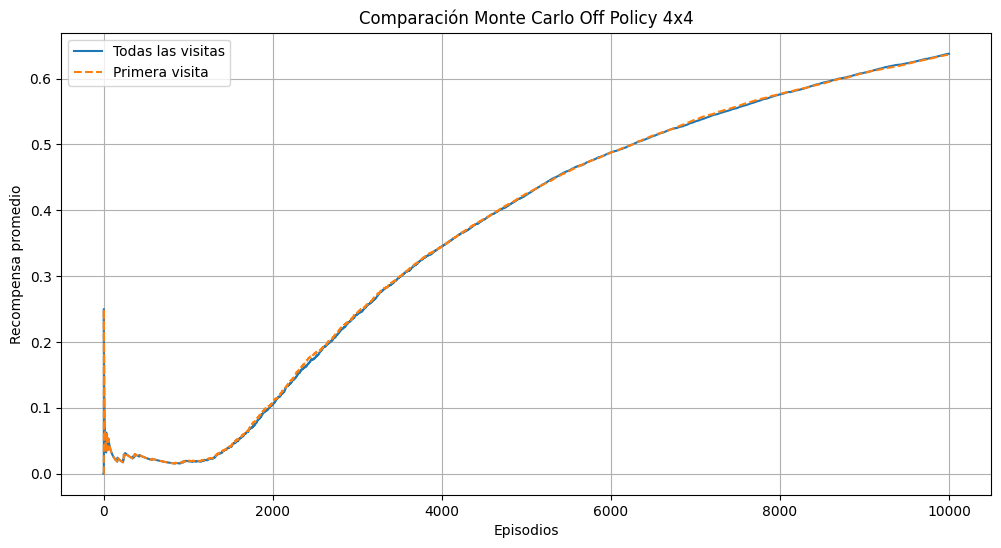

Máxima proporcion Monte Carlo todas las visitas: 0.6377
Máxima proporcion Monte Carlo primera visita: 0.6365


In [15]:
# @title Recompensa promedio Monte Carlo Off-Policy en el escenario 4x4

crear_grafica_recompensa_promedio(
    recompensa_1 = list_stats_MC_Off_V4_all, 
    recompensa_2 = list_stats_MC_Off_V4_first, 
    label1 = "Todas las visitas", 
    label2 = "Primera visita", 
    titulo = "Comparación Monte Carlo Off Policy 4x4")

print(f"Máxima proporcion Monte Carlo todas las visitas: {list_stats_MC_Off_V4_all[-1]}")
print(f"Máxima proporcion Monte Carlo primera visita: {list_stats_MC_Off_V4_first[-1]}")

En la gráfica aparece la recompensa promedio a lo largo de 10000 episodios. En una línea naranja aparece la recompensa del algoritmo de la primera visita, y en azul el algoritmo de todas las visitas.

En esta gráfica, la recompensa de ambos algoritmos es similar durante todo el entrenamiento. Al inicio la recompensa es poca, y a partir de unos 1000 pasos empieza a subir de forma constante, hasta un final de 0.6377 y 0.6365 (valores muy cercanos en ambos algoritmos), es decir, un 63% de las ocasiones se llega a la meta.

A continuación, se muestra la longitud de los episodios a lo largo del entrenamiento.

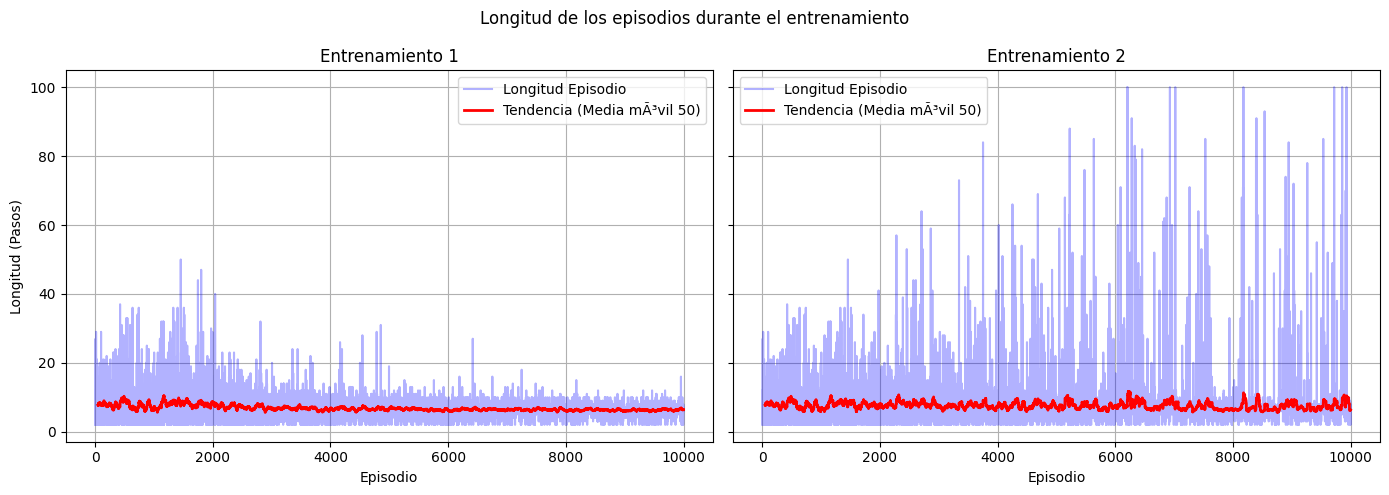

In [16]:
# @title Longitud de los episodios Monte Carlo Off-Policy en el escenario 4x4
plot_two_lengths(all_episode_lengths_MC_Off_V4_all, all_episode_lengths_MC_Off_V4_first)

La longitud de los episodios media se mantiene constante en todos los episodios. Se recuerda que los episodios donde se cae en un agujero en vez de llegar a la meta, también pueden tener pocos pasos y aún así ser malos.

En el algoritmo de todas las visitas, hay poca varianza, siendo en su mayoría menor a 40 en todos los pasos, y reduciéndose desde el inicio hasta el final del entrenamiento.

Sin embargo, para el algoritmo de la primera visita, se muestra una varianza mucho mayor, llegando al límite de pasos en unas pocas ocasiones, incluso al final del entrenamiento.

A continuación, se muestra la política greedy de ambos algoritmos.

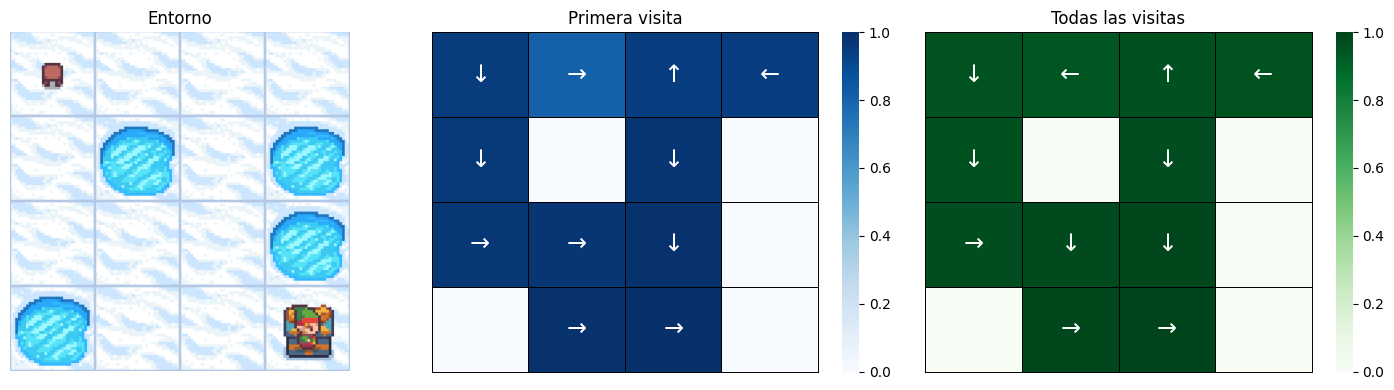

In [17]:
# @title Mostrar el entorno y las políticas greedy de Monte Carlo Off-Policy en el escenario 4x4
mostrar_entorno_y_politicas(
    env=env4,
    qtable_1=agente_MC_Off_V4_first.Q,
    titulo_1="Primera visita",
    qtable_2=agente_MC_Off_V4_all.Q,
    titulo_2="Todas las visitas",
    map_size=4
)

Como se puede observar, los agujeros no tienen una acción asignada porque una vez se cae en un agujero, finaliza el episodio. Ocurre lo mismo con la meta.

Por otra parte, los algoritmos no aprenden los mismos caminos exactos, pero ambos aprenden un camino a la meta. A su vez, los algoritmos muestran el mismo nivel de confianza visible en casi todos los estados. Dado que el factor de confianza es 0.99, no es visible la disminución en pocos pasos.

#### **3.1.3 on-policy vs off-policy**

Por último, se compara el aprendizaje off policy y on policy. Dado que ambos tienen resultados igual de buenos tanto en la variante todas las visitas como en la primera visita, se comparan las variaciones de todas las visitas.

En primer lugar, se muestra la comparativa de recompensas promedio.

In [1]:
# @title Recompensa promedio Monte Carlo Off/On-Policy en el escenario 4x4

crear_grafica_recompensa_promedio(
    recompensa_1 = list_stats_MC_On_V4_all, 
    recompensa_2 = list_stats_MC_Off_V4_all, 
    label1 = "On-policy", 
    label2 = "Off-policy", 
    titulo = "Comparación Monte Carlo Off-Policy y On-Policy 4x4")

print(f"Máxima proporcion Monte Carlo on-policy: {list_stats_MC_On_V4_all[-1]}")
print(f"Máxima proporcion Monte Carlo off-policy: {list_stats_MC_Off_V4_all[-1]}")

NameError: name 'crear_grafica_recompensa_promedio' is not defined

Se observa un promedio máximo similar en ambos casos, y una evolución de la recompensa promedio similar.

A continuación, se la diferencia entre longitudes de episodios durante el entrenamiento

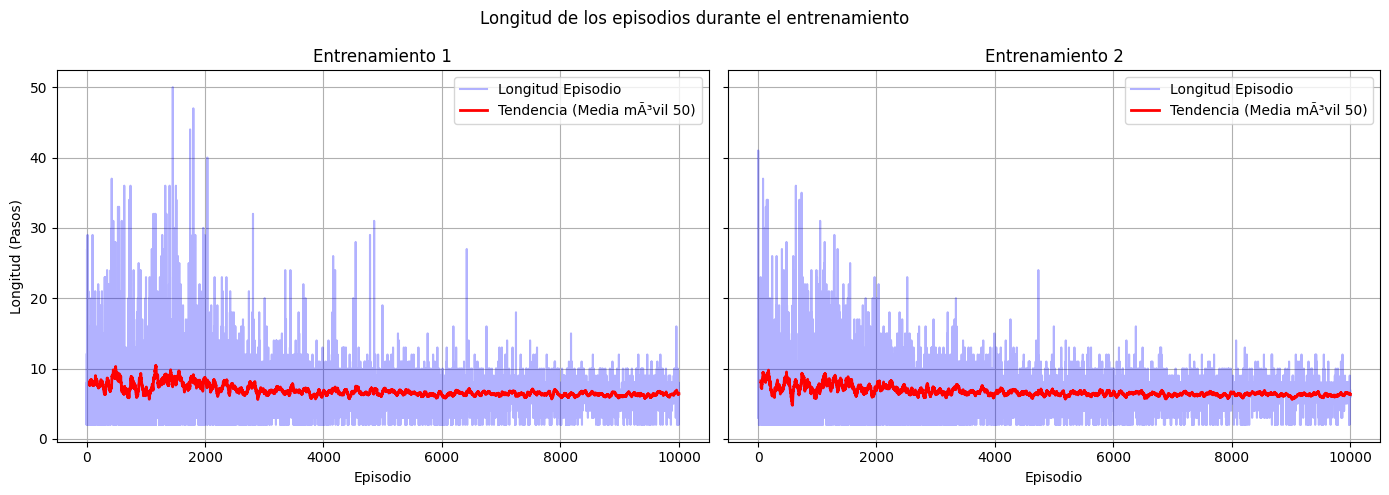

In [ ]:
# @title Longitud de los episodios Monte Carlo Off/On-Policy en el escenario 4x4
plot_two_lengths(all_episode_lengths_MC_Off_V4_all, all_episode_lengths_MC_On_V4_all)

Se observa una longitud silimar, con una varianza muy ligeramente mayor en monte carlo off policy.

Por último, se enseña la política greedy de los agentes.

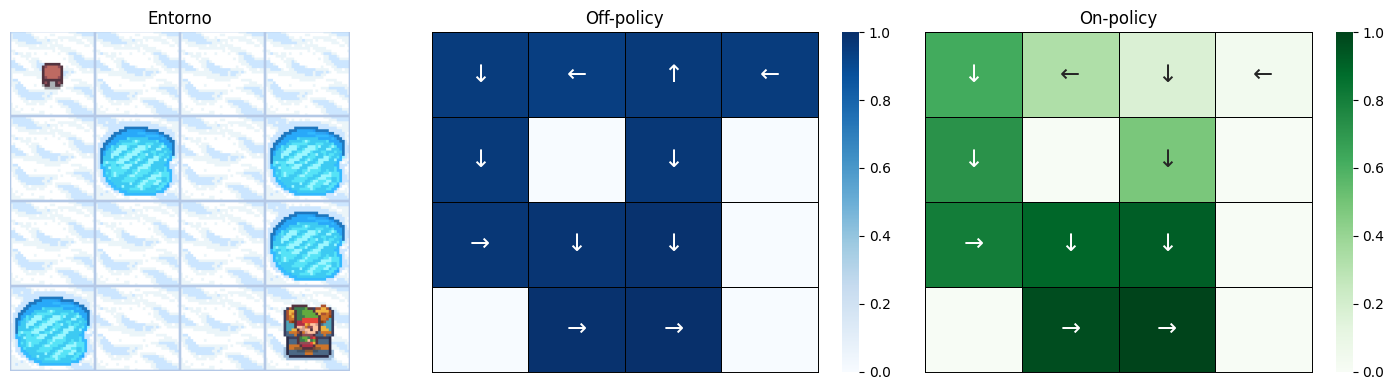

In [ ]:
# @title Mostrar el entorno y las políticas greedy de Monte Carlo Off/On-Policy en el escenario 4x4
mostrar_entorno_y_politicas(
    env=env4,
    qtable_1=agente_MC_Off_V4_all.Q,
    titulo_1="Off-policy",
    qtable_2=agente_MC_On_V4_all.Q,
    titulo_2="On-policy",
    map_size=4
)

Aunque ambos aprender el camino a la meta, dado que on policy aprende de datos generados por una política epsilon-decaimiento, en ocasiones se cae en agujeros, por lo que los estados que más alejados están de la meta, al haberse caido más en agujeros, tienen un color más claro.

### **3.2 Experimentación en el escenario 8x8**

A continuación, se realiza la experimentación del escenario 8x8.

#### **3.2.1 Algoritmo Montecarlo On Policy**

A continuación, se realiza el aprendizaje de los modelos para primera visita y todas las visitas.

In [21]:
# @title Aprendizaje Monte Carlo On-Policy en el escenario 8x8

# Monte Carlo todas las visitas
print("Ejecución de Monte Carlo de todas las visitas:")

agente_MC_On_V8_all = AgenteMC_OnPolicy(
    env8, 
    seed, 
    discount_factor=FACTOR_DESCUENTO, 
    epsilon=EPSILON_INICIAL, 
    decay=DECAIMIENTO, 
    num_episodes=NUM_EPISODIOS_8x8)

list_stats_MC_On_V8_all, all_episode_lengths_MC_On_V8_all = monte_carlo_all_visit(
    env8, 
    agente=agente_MC_On_V8_all, 
    num_episodes=NUM_EPISODIOS_8x8)

# Monte Carlo con primera visita
print("-"*20)
print("Ejecución de Monte Carlo de la primera visita:")

agente_MC_On_V8_first = AgenteMC_OnPolicy(
    env8, 
    seed, 
    discount_factor=FACTOR_DESCUENTO, 
    epsilon=EPSILON_INICIAL, 
    decay=DECAIMIENTO, 
    num_episodes=NUM_EPISODIOS_8x8)

list_stats_MC_On_V8_first, all_episode_lengths_MC_On_V8_first = monte_carlo_first_visit(
    env8, 
    agente=agente_MC_On_V8_first, 
    num_episodes=NUM_EPISODIOS_8x8)

Ejecución de Monte Carlo de todas las visitas:


 10%|█         | 5175/50000 [00:05<00:44, 1013.74it/s]

Episode: 5000, Avg Return: 0.49, Epsilon: 0.200


 21%|██        | 10269/50000 [00:08<00:16, 2418.39it/s]

Episode: 10000, Avg Return: 0.69, Epsilon: 0.100


...

 81%|████████  | 40347/50000 [00:21<00:03, 2566.61it/s]

Episode: 40000, Avg Return: 0.90, Epsilon: 0.025


 91%|█████████ | 45366/50000 [00:23<00:01, 2525.25it/s]

Episode: 45000, Avg Return: 0.91, Epsilon: 0.022


100%|██████████| 50000/50000 [00:25<00:00, 1990.51it/s]


Una vez realizado el aprendizaje de la primera visita y todas las visitas, se muestra la recompensa promedio.

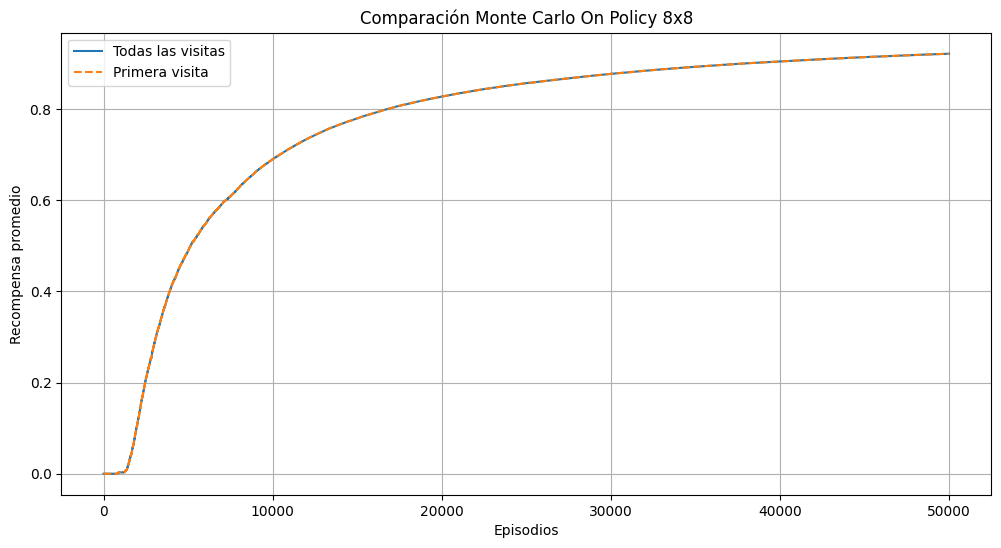

Máxima proporcion Monte Carlo todas las visitas: 0.9217
Máxima proporcion Monte Carlo primera visita: 0.9217


In [22]:
# @title Recompensa promedio Monte Carlo On-Policy en el escenario 8x8

crear_grafica_recompensa_promedio(
    recompensa_1 = list_stats_MC_On_V8_all, 
    recompensa_2 = list_stats_MC_On_V8_first, 
    label1 = "Todas las visitas", 
    label2 = "Primera visita", 
    titulo = "Comparación Monte Carlo On Policy 8x8")

print(f"Máxima proporcion Monte Carlo todas las visitas: {list_stats_MC_On_V8_all[-1]}")
print(f"Máxima proporcion Monte Carlo primera visita: {list_stats_MC_On_V8_first[-1]}")

En la gráfica aparece la recompensa promedio a lo largo de 50000 episodios. En una línea naranja aparece la recompensa del algoritmo de la primera visita, y en azul el algoritmo de todas las visitas.

En esta gráfica, la recompensa de ambos algoritmos es similar durante todo el entrenamiento. Al inicio la recompensa es 0, mostrando que no llega a la meta, y a partir de menos de 200 pasos empieza a subir de forma constante, más elevada al inicio que al final, hasta conseguir una proporción máxima del 92.17% en ambos algoritmos.

A continuación, se muestra la longitud de los episodios a lo largo del entrenamiento.

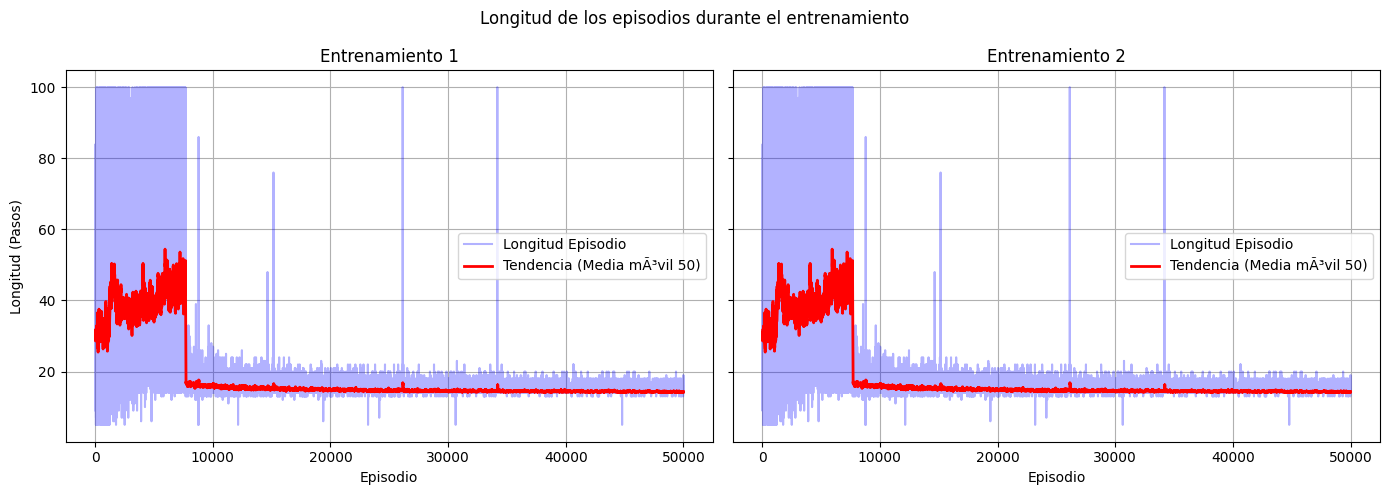

In [23]:
# @title Longitud de los episodios Monte Carlo On-Policy en el escenario 8x8
plot_two_lengths(all_episode_lengths_MC_On_V8_all, all_episode_lengths_MC_On_V8_first)

La longitud de los episodios media es más elevada al inicio y baja antes de los 1000 pasos. Esto podría deberse a la falta de recompensa, al no poder llegar al final, en muchos episodios en lugar de caer en agujeros da vueltas hasta llegar al límite de pasos por episodio (100). Tras estos 1000 primeros pasos, se reduce la varianza y también el número de pasos por episodio.

A continuación, se muestra la política greedy de ambos algoritmos.

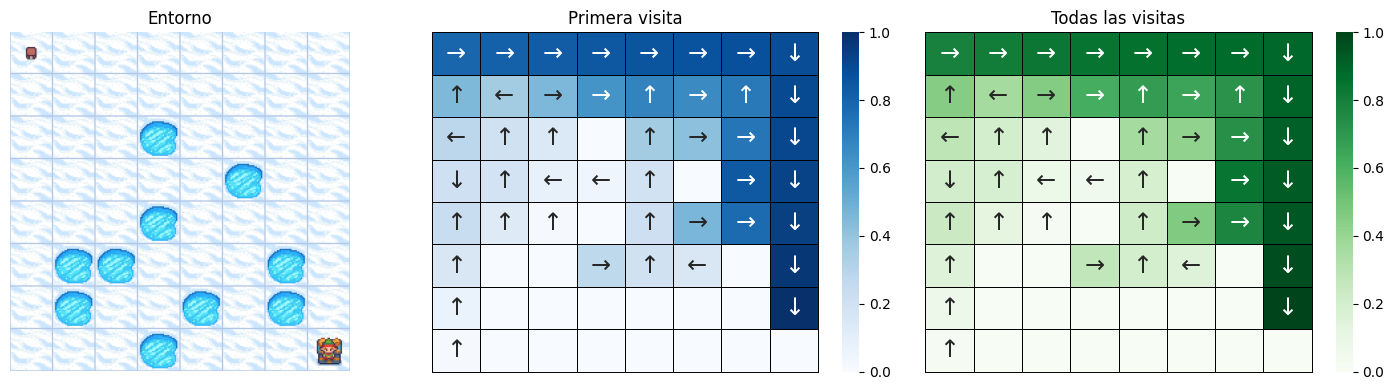

In [24]:
# @title Mostrar el entorno y las políticas greedy de Monte Carlo On-Policy en el escenario 8x8
mostrar_entorno_y_politicas(
    env=env8,
    qtable_1=agente_MC_On_V8_first.Q,
    titulo_1="Primera visita",
    qtable_2=agente_MC_On_V8_all.Q,
    titulo_2="Todas las visitas",
    map_size=8
)

Como se puede observar, los agujeros no tienen una acción asignada porque una vez se cae en un agujero, finaliza el episodio. Ocurre lo mismo con la meta. Otros que no son ni agujeros ni la meta tampoco tienen acciones asignadas, seguramente porque están tan alejados del inicio y de la meta que pocas veces se llega a estos estados.

Por otra parte, se observa como ambos algoritmos aprenden los mismos caminos. A su vez, cuanto más cerca se encuentra de la meta más color tiene la flecha, con un cambio de intensidad de color muy leve, dado que el factor de descuento utilizado en el aprendizaje disminuye la recompensa cuantó más alejado del estado que ha dado esta recompensa, pero al ser 0.99 se nota poco.

Por otro lado, cuanto más cercano a agujeros menos intensidad de color. Esto se debe a que, dado que se usa una política que aprendió con epsilon-decaimiento, cuanto más alejado de la meta, más probabilidad que en esa parte exploratoria se escogiera una acción en un estado que terminase en caer en un agujero.

#### **3.2.2 Algoritmo Montecarlo Off policy**

A continuación, se realiza el aprendizaje de los modelos para primera visita y todas las visitas.

In [25]:
# @title Aprendizaje Monte Carlo Off-Policy en el escenario 8x8

# Monte Carlo todas las visitas
print("Ejecución de Monte Carlo de todas las visitas:")

agente_MC_Off_V8_all = AgenteMC_OffPolicy(
    env8, 
    seed, 
    discount_factor=FACTOR_DESCUENTO, 
    epsilon=EPSILON_INICIAL, 
    decay=DECAIMIENTO, 
    num_episodes=NUM_EPISODIOS_8x8)

list_stats_MC_Off_V8_all, all_episode_lengths_MC_Off_V8_all = monte_carlo_all_visit(
    env8, 
    agente=agente_MC_Off_V8_all, 
    num_episodes=NUM_EPISODIOS_8x8)

# Monte Carlo con primera visita
print("-"*20)
print("Ejecución de Monte Carlo de la primera visita:")

agente_MC_Off_V8_first = AgenteMC_OffPolicy(
    env8, 
    seed, 
    discount_factor=FACTOR_DESCUENTO, 
    epsilon=EPSILON_INICIAL, 
    decay=DECAIMIENTO, 
    num_episodes=NUM_EPISODIOS_8x8)

list_stats_MC_Off_V8_first, all_episode_lengths_MC_Off_V8_first = monte_carlo_first_visit(
    env8, 
    agente=agente_MC_Off_V8_first, 
    num_episodes=NUM_EPISODIOS_8x8)

Ejecución de Monte Carlo de todas las visitas:


 11%|█         | 5303/50000 [00:02<00:23, 1924.56it/s]

Episode: 5000, Avg Return: 0.23, Epsilon: 0.200


 21%|██        | 10345/50000 [00:04<00:15, 2588.50it/s]

Episode: 10000, Avg Return: 0.52, Epsilon: 0.100


...

 81%|████████  | 40574/50000 [00:15<00:03, 2848.51it/s]

Episode: 40000, Avg Return: 0.86, Epsilon: 0.025


 91%|█████████ | 45499/50000 [00:17<00:01, 2832.98it/s]

Episode: 45000, Avg Return: 0.87, Epsilon: 0.022


100%|██████████| 50000/50000 [00:19<00:00, 2569.91it/s]


Una vez realizado el aprendizaje de la primera visita y todas las visitas, se muestra la recompensa promedio.

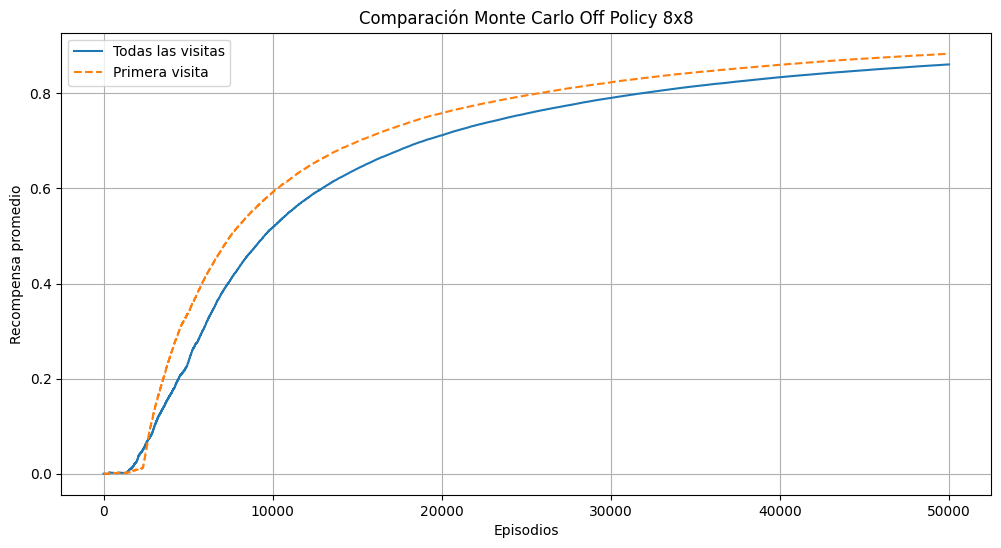

Máxima proporcion Monte Carlo todas las visitas: 0.86082
Máxima proporcion Monte Carlo primera visita: 0.8833


In [26]:
# @title Recompensa promedio Monte Carlo Off-Policy en el escenario 8x8

crear_grafica_recompensa_promedio(
    recompensa_1 = list_stats_MC_Off_V8_all, 
    recompensa_2 = list_stats_MC_Off_V8_first, 
    label1 = "Todas las visitas", 
    label2 = "Primera visita", 
    titulo = "Comparación Monte Carlo Off Policy 8x8")

print(f"Máxima proporcion Monte Carlo todas las visitas: {list_stats_MC_Off_V8_all[-1]}")
print(f"Máxima proporcion Monte Carlo primera visita: {list_stats_MC_Off_V8_first[-1]}")

En la gráfica aparece la recompensa promedio a lo largo de 50000 episodios. En una línea naranja aparece la recompensa del algoritmo de la primera visita, y en azul el algoritmo de todas las visitas.

En esta gráfica, la recompensa de la primera visita es ligeramente mayor durante todo el aprendizaje, llegando a la meta en un máximo del 88% de las ocasiones, frente al 86% al usar el algoritmo de la primera visita.

A continuación, se muestra la longitud de los episodios a lo largo del entrenamiento.

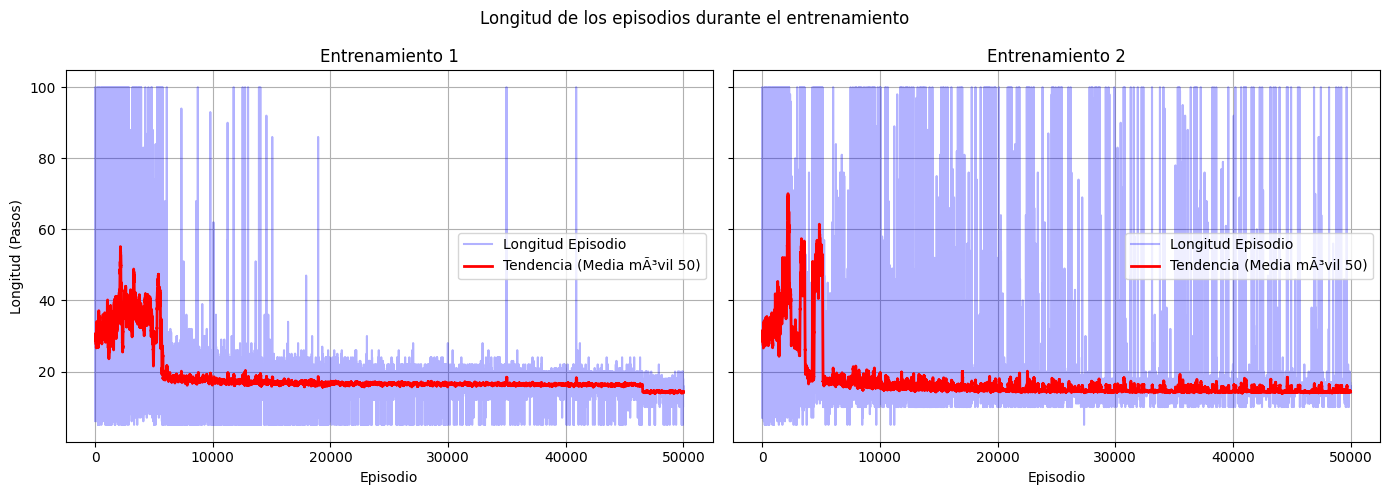

In [27]:
# @title Longitud de los episodios Monte Carlo Off-Policy en el escenario 8x8
plot_two_lengths(all_episode_lengths_MC_Off_V8_all, all_episode_lengths_MC_Off_V8_first)

La longitud de los episodios media es más elevada al inicio y baja antes de los 1000 pasos. Esto podría deberse a la falta de recompensa al inicio, al no poder llegar al final, en muchos episodios en lugar de caer en agujeros da vueltas hasta llegar al límite de pasos por episodio (100). Durante estos 1000 primeros episodios, el número de pasos por episodio disminuye, lo que es consistente con la anterior gráfica, en la que en los primeros mil episodios aumenta considerablemente la recompensa promedio (cantidad de veces que se llega a la meta) en ambos algoritmos.

Sin embargo, el algoritmo de todas las visitas logra mucha menor varianza a partir de los 1000 episodios, lo que no ocurre en el algoritmo de la primera visita, que muchas más veces llega al límite de pasos, aunque se aprenda el camino (que se refleja en el aumento de recompensa promedio visto en la anterior gráfica).

A continuación, se muestra la política greedy de ambos algoritmos.

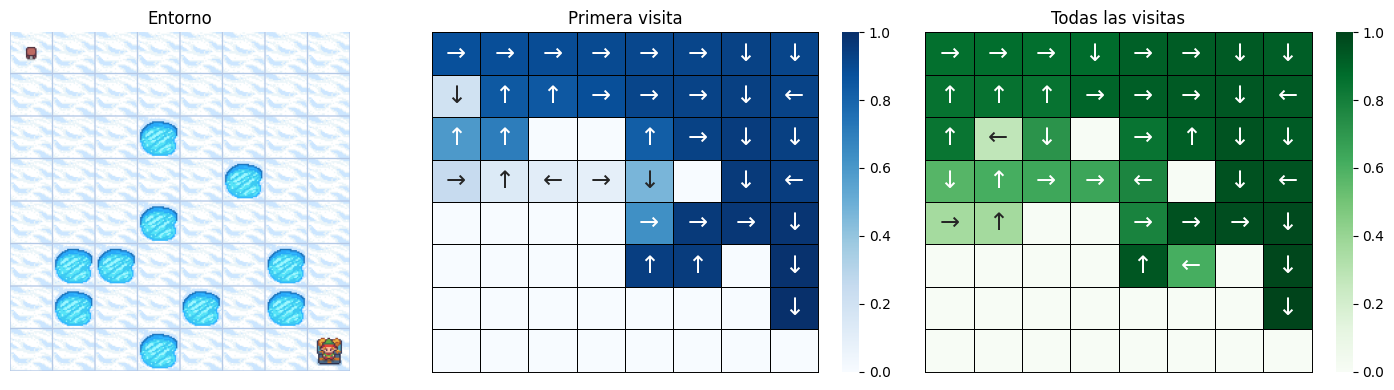

In [28]:
# @title Mostrar el entorno y las políticas greedy de Monte Carlo Off-Policy en el escenario 8x8
mostrar_entorno_y_politicas(
    env=env8,
    qtable_1=agente_MC_Off_V8_first.Q,
    titulo_1="Primera visita",
    qtable_2=agente_MC_Off_V8_all.Q,
    titulo_2="Todas las visitas",
    map_size=8
)

Como se puede observar, los agujeros no tienen una acción asignada porque una vez se cae en un agujero, finaliza el episodio. Ocurre lo mismo con la meta. Otros que no son ni agujeros ni la meta tampoco tienen acciones asignadas, seguramente porque están tan alejados del inicio y de la meta que pocas veces se llega a estos estados o se actualiza (la política actual no es igual a la que se está aprendiendo). 

Por otra parte, se observa como ambos algoritmos aprenden un camino más corto a la meta, aunque este no es el mismo para ambos.

#### **3.2.3 on-policy vs off-policy**

Por último, se compara el aprendizaje off policy y on policy. Dado que el algoritmo off policy tiene mejores resultados en todas las visitas, y el algoritmo on policy tiene rsultados similares en primera y todas las visitas, se comparan las variaciones de todas las visitas.

En primer lugar, se muestra la comparativa de recompensas promedio.

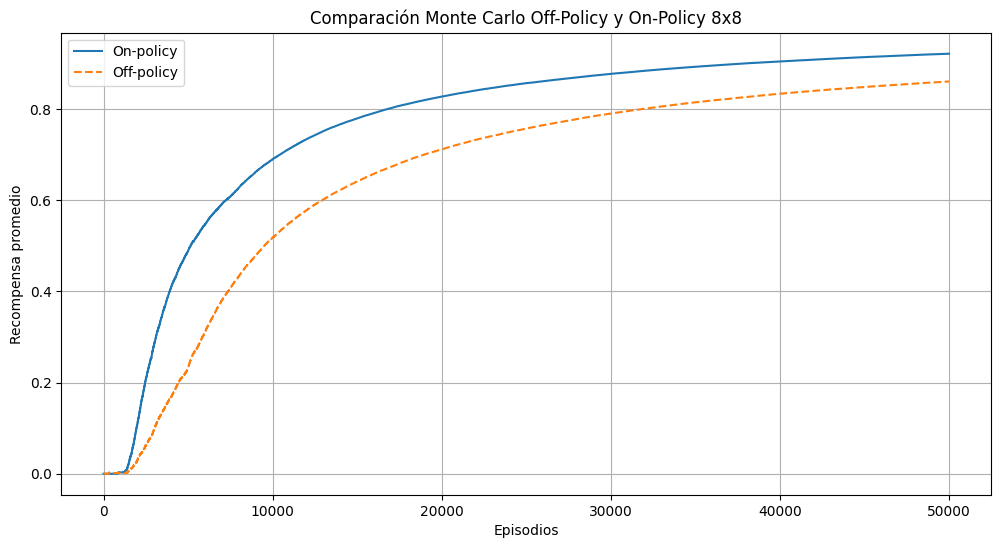

Máxima proporcion Monte Carlo on-policy: 0.9217
Máxima proporcion Monte Carlo off-policy: 0.86082


In [29]:
# @title Recompensa promedio Monte Carlo Off/On-Policy en el escenario 8x8

crear_grafica_recompensa_promedio(
    recompensa_1 = list_stats_MC_On_V8_all, 
    recompensa_2 = list_stats_MC_Off_V8_all, 
    label1 = "On-policy", 
    label2 = "Off-policy", 
    titulo = "Comparación Monte Carlo Off-Policy y On-Policy 8x8")

print(f"Máxima proporcion Monte Carlo on-policy: {list_stats_MC_On_V8_all[-1]}")
print(f"Máxima proporcion Monte Carlo off-policy: {list_stats_MC_Off_V8_all[-1]}")

Se observa una diferencia significativa entre el algoritmo off policy y on policy, dado que el algoritmo on policy funciona de mejor forma y aumenta la recompensa de forma más rápida.

A continuación, se la diferencia entre longitudes de episodios durante el entrenamiento

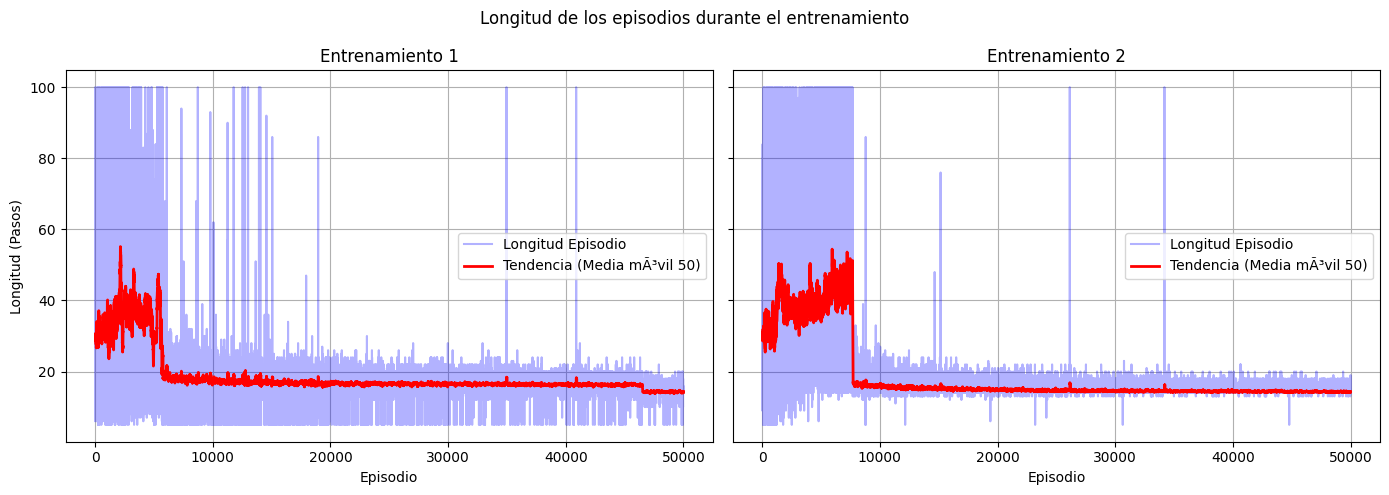

In [30]:
# @title Longitud de los episodios Monte Carlo Off/On-Policy en el escenario 8x8
plot_two_lengths(all_episode_lengths_MC_Off_V8_all, all_episode_lengths_MC_On_V8_all)

Se observa como ambos algoritmos tienen un periodo de gran variación al inicio, y cuando las recompensas comienzan a aparecer (llega a la meta) y empieza a aprender el camino a la meta, la varianza disminuye.

Se puede observar una menor varianza en el algoritmo on policy.

Por último, se enseña la política greedy de los agentes.

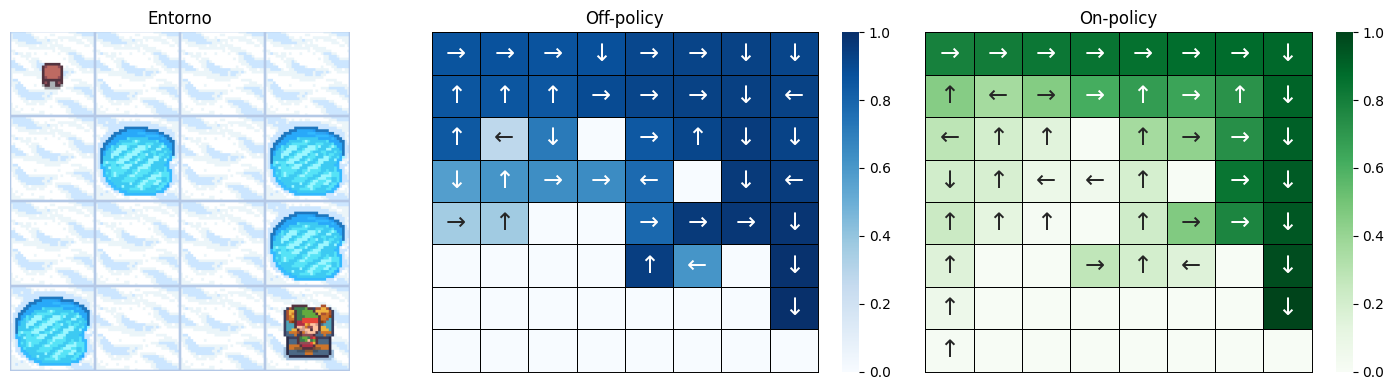

In [31]:
# @title Mostrar el entorno y las políticas greedy de Monte Carlo Off/On-Policy en el escenario 8x8
mostrar_entorno_y_politicas(
    env=env4,
    qtable_1=agente_MC_Off_V8_all.Q,
    titulo_1="Off-policy",
    qtable_2=agente_MC_On_V8_all.Q,
    titulo_2="On-policy",
    map_size=8
)

Ambos aprenden uno de los caminos más cortos a la meta, siendo el camino distinto para ambos.

Al igual que en 4x4, dado que on policy aprende de datos generados por una política epsilon-decaimiento, en ocasiones se cae en agujeros, por lo que los estados que más alejados están de la meta, al haberse caido más en agujeros, tienen un color más claro.

## **4. Análisis y Estudios Futuros**

### **4.1 Análisis de Resultados**
Aunque en muchas ocasiones las variantes se hayan visto con comportamientos similares, se han notado ciertas diferencias. 

Se notan mayor diferencia en entornos más complejos, 8x8, que en 4x4.

En 8x8, se ha notado que todas las visitas tiene mayor varianza que la primera visita en algunas ocasiones, y que on policy muestra más acciones para los estados y menos recompensa esperada dado que en ocasiones se cae en agujeros en la exploración, lo que se tiene en cuenta en on policy, pero no en off policy.

### **4.2 Propuestas para Estudios Futuros**

Como propuesta para estudios futuros, se propone la prueba de estos algoritmos en el entorno resbaladizo.